# Module 1 – Homework Assignment



## General Information

**Written Report.**  
The written report should be concise and written in such a way that it is perfectly clear what has been done and why. Solutions to programming oriented tasks are required to be written in word processing software, such as Latex, MS Word, or equivalent. However, solutions to math oriented tasks are not required to be written in word processing software. Submit your report in pdf format to Studium. You can scan or take a photo of your hand-written tasks and convert them to pdf. Include the software code in your report, if any.

**Group Work.**  
Teamwork is highly recommended. Please sign up groups yourself at Studium. Each group should consist of no more than 3 students. An individual report is also permitted, but not encouraged.

**Grading.**  
Handing in a report means that the group members take equal responsibilities for the content of the report and group members will earn equal points. The grades are only PASS and FAIL. Remember that you need to pass the HWAs in order to get whole credits. In order to pass the HWA, you need at least 5 points out 10 points. If you fail the HWA, you need to revise it.

**Plagiarism and misconduct**.  
The assignment must be done without collaboration or help from other groups. You may reference and cite other sources (e.g., books, articles, websites, etc.), but sharing such information with others is prohibited. You are not allowed to create any posts online to seek help. **Note:** This is part of your examination.

**Generative AI interfaces**.  
Using generative AI interfaces (e.g., ChatGPT, Gemini, etc) to solve tasks is strictly **prohibited**.

## Exercise 1
1. {2p} A machine operates daily and independently fails on any given day with probability 
$p = 0.3$. Over a period of 20 days, let $X_i$ indicate whether a failure occurs on day $i$, and define

$$
S_{20} = \sum_{i=1}^{20} X_i,
$$

the total number of failures.

(a) What is the distribution of $S_{20}$? State its parameters.

(b) Compute the theoretical mean and variance.

(c) Simulate 10,000 such 20-day periods and estimate the sample mean.

(d) Estimate the probability that the machine fails at least 8 times during the 20-day period. Compute both the exact binomial probability and a sample estimate based on simulation. Compare the two values.


### Solution

(a) Each day the machine either fails or does not fail. This can be modeled by a Bernoulli random variable
$$
X_i \in \{0,1\}, \quad P(X_i=1)=p=0.3,
$$
where $X_i=1$ means “a failure occurs on day $i$”. The total number of failures over 20 days is
$$
S_{20}=\sum_{i=1}^{20}X_i.
$$
A sum of $n$ independent Bernoulli$(p)$ trials has a binomial distribution, so
$$
S_{20}\sim \mathrm{Binomial}(n=20,\;p=0.3).
$$

(b) If $S_{20}\sim \mathrm{Binomial}(n,p)$, then
$$
E[S_{20}] = np, \qquad \mathrm{Var}(S_{20}) = np(1-p).
$$
With $n=20$ and $p=0.3$,
$$
E[S_{20}] = 20\cdot 0.3 = 6,
$$
and
$$
\mathrm{Var}(S_{20}) = 20\cdot 0.3\cdot (1-0.3) = 20\cdot 0.3\cdot 0.7 = 4.2.
$$

(c) To estimate the sample mean, we simulate many independent 20-day periods. 
Each period consists of 20 independent Bernoulli trials with success probability $p=0.3$. 
For each period, we compute the total number of failures.

In [14]:
import numpy as np

np.random.seed(42)

n = 20
p = 0.3
N = 10000

samples = np.random.binomial(n, p, size=N)
sample_mean = samples.mean()

print("Sample mean:", round(sample_mean, 2))

Sample mean: 5.96


(d) We compute the exact probability and compare it with a sample estimate based on simulation.

In [15]:
from scipy.stats import binom
import numpy as np

theoretical_prob = 1 - binom.cdf(7, 20, 0.3)
sample_prob = np.mean(samples >= 8)

print("Theoretical probability:", round(theoretical_prob, 4))
print("Sample estimate:", round(sample_prob, 4))

Theoretical probability: 0.2277
Sample estimate: 0.22


## Exercise 2
2. {2p} Suppose that disturbances in a power system occur according to a Poisson process with intensity $6$ events per year. Let
$$
X(t)=\text{number of disturbances in the time interval }[0,t],\quad t\ge 0.
$$

(a) Compute $P\big(X(1/4)=0\big)$.

(b) Compute $P\big(X(1/2)=1\big)$.

(c) Compute $P\big(X(1/4)=1 \mid X(1/2)=1\big)$.

(d) Use simulation to estimate $P\big(X(1/4)=1 \mid X(1/2)=1\big)$ and the complementary probabilities
$$
P\big(X(1/4)=0 \mid X(1/2)=1\big).
$$
Compare the estimates for $\lambda=2, 6, 10$. Briefly explain why the estimates should be close to $1/2$ for all values of $\lambda$.




### Solution

(a) For a Poisson process with intensity $\lambda=6$ events per year,
$$
X(t)\sim \mathrm{Poisson}(\lambda t).
$$
Thus $X(1/4)\sim \mathrm{Poisson}(6\cdot 1/4)=\mathrm{Poisson}(3/2)$, and
$$
P\big(X(1/4)=0\big)=e^{-3/2}.
$$

(b) Similarly, $X(1/2)\sim \mathrm{Poisson}(6\cdot 1/2)=\mathrm{Poisson}(3)$, so
$$
P\big(X(1/2)=1\big)=e^{-3}\frac{3^1}{1!}=3e^{-3}.
$$


(c) Let $A=X(1/4)$ and $B=X(1/2)-X(1/4)$. By independent increments, $A$ and $B$ are independent and
$$
A\sim \mathrm{Poisson}(3/2),\qquad B\sim \mathrm{Poisson}(3/2),
$$
so $A+B=X(1/2)\sim \mathrm{Poisson}(3)$. Then
$$
P\big(X(1/4)=1\mid X(1/2)=1\big)=P(A=1\mid A+B=1)
=\frac{P(A=1,B=0)}{P(A+B=1)}
=\frac{P(A=1)P(B=0)}{P(A+B=1)}
=\frac{1}{2}.
$$

(d) Condition on the event $\{X(1/2)=1\}$. This means that exactly one event occurred in the interval $[0,1/2]$. Given this condition, the event time is equally likely to fall anywhere in $[0,1/2]$. Therefore, the probability that it falls in the first quarter $[0,1/4]$ is
$$
\frac{|[0,1/4]|}{|[0,1/2]|}=\frac{1/4}{1/2}=\frac{1}{2},
$$
which does not depend on $\lambda$. Small deviations from $0.5$ in the simulation are due to Monte Carlo sampling variability and the fact that we condition on a relatively rare event when $\lambda$ is very small or very large.

In [16]:
import numpy as np

np.random.seed(42)

def estimate_conditional(lam, N=50000):
    mu_q = lam * 0.25
    A = np.random.poisson(mu_q, size=N)      # X(1/4)
    B = np.random.poisson(mu_q, size=N)      # X(1/2) - X(1/4)
    X_half = A + B                           # X(1/2)

    mask = (X_half == 1)
    return np.mean(A[mask] == 1)

for lam in [6, 2, 10]:
    est = estimate_conditional(lam, N=50000)
    print("lambda =", lam, " estimate =", round(est, 4))

lambda = 6  estimate = 0.5039
lambda = 2  estimate = 0.5016
lambda = 10  estimate = 0.4877


## Exercise 3
3. {3p} Let $\{N(t)\}$ be a Poisson process with intensity $\lambda = 2$ events per hour, and let $T_1, T_2, \dots$ denote the interarrival times.

(a) Simulate $N=10{,}000$ interarrival times and make a histogram overlaid with the theoretical exponential density. Repeat the plot with $N=50$ and with $N=20{,}000$, and comment briefly on the differences.

(b) Simulate one trajectory of the arrival times
$$
S_n = T_1 + \cdots + T_n
$$
until $S_n > 5$, and plot the counting process $N(t)$ on the time interval $[0,5]$.

(c) Repeat (b) and plot $M=5$ sample paths of $N(t)$ in the same figure.


### Solution

We consider a Poisson process with intensity $\lambda=2$ events per hour. The interarrival times $T_i$ are i.i.d. exponential with parameter $\lambda$, with density $f(t)=\lambda e^{-\lambda t}$ for $t\ge 0$.

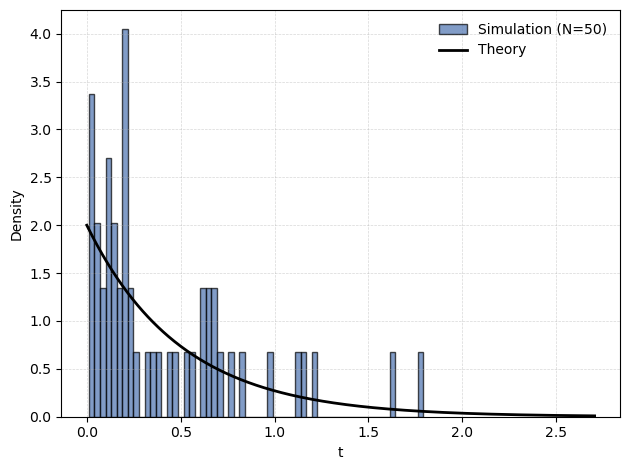

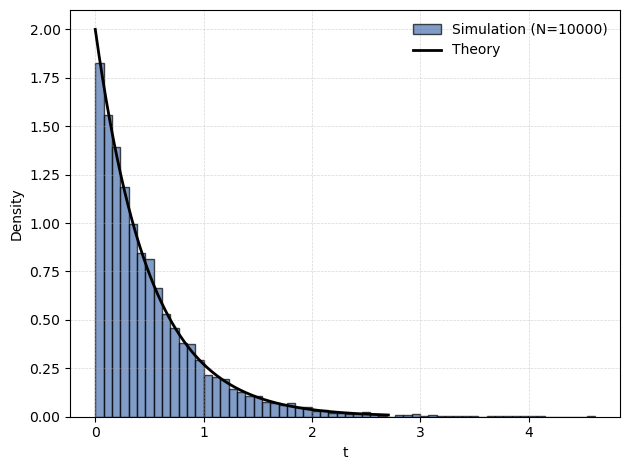

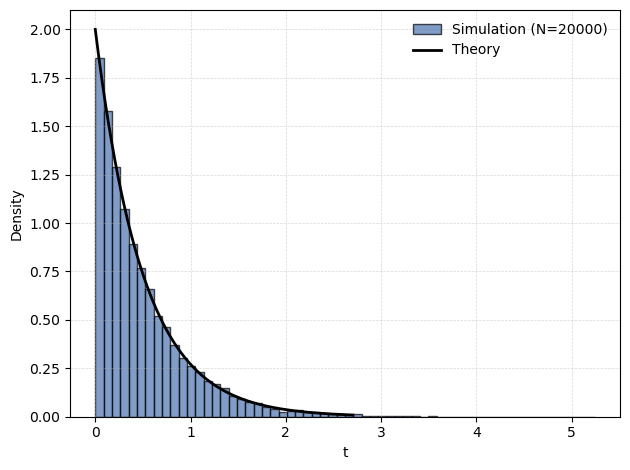

In [17]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

lam = 2.0
Ns = [50, 10000, 20000]

T_ref = np.random.exponential(scale=1/lam, size=max(Ns))
x_max = np.quantile(T_ref, 0.995)
x = np.linspace(0, x_max, 400)
pdf = lam * np.exp(-lam * x)

def plot_hist_with_pdf(T, N):
    fig, ax = plt.subplots()

    ax.hist(T, bins=60, density=True, edgecolor="black",
            color="#4C72B0", alpha=0.7, label=f"Simulation (N={N})")
    ax.plot(x, pdf, color="black", linewidth=2, label="Theory")

    ax.set_xlabel("t")
    ax.set_ylabel("Density")
    ax.set_ylim(bottom=0)

    for side in ["top", "right", "left", "bottom"]:
        ax.spines[side].set_visible(True)

    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
    ax.legend(frameon=False)

    plt.tight_layout()
    plt.show()

for N in Ns:
    T = np.random.exponential(scale=1/lam, size=N)
    plot_hist_with_pdf(T, N)

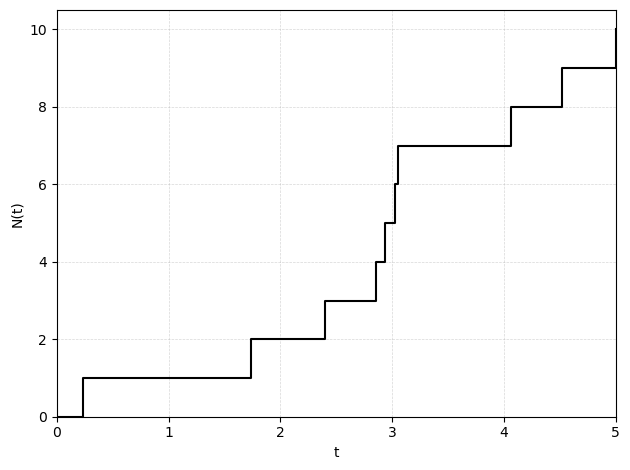

In [7]:
np.random.seed(42)

lam = 2.0
T_max = 5.0

arrival_times = []
t = 0.0
while True:
    t += np.random.exponential(scale=1/lam)
    if t > T_max:
        break
    arrival_times.append(t)

arrival_times = np.array(arrival_times)

times = np.concatenate(([0.0], arrival_times, [T_max]))
counts = np.arange(0, len(times))

fig, ax = plt.subplots()
ax.step(times, counts, where="post", color="black", linewidth=1.5)

ax.set_xlabel("t")
ax.set_ylabel("N(t)")
ax.set_xlim(0, T_max)
ax.set_ylim(bottom=0)

for side in ["top", "right", "left", "bottom"]:
    ax.spines[side].set_visible(True)

ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

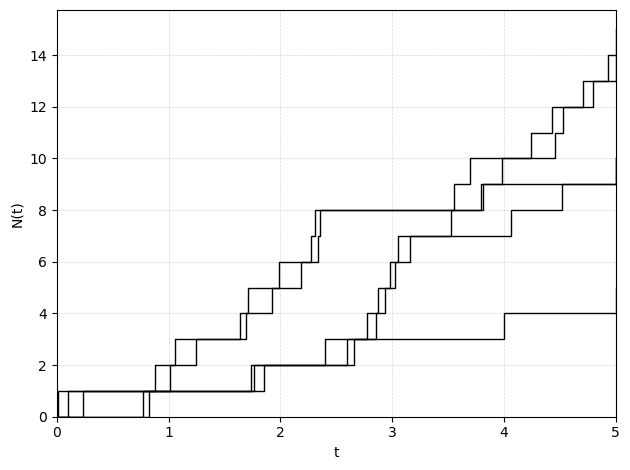

In [8]:
np.random.seed(42)

lam = 2.0
T_max = 5.0
M = 5

fig, ax = plt.subplots()

for _ in range(M):
    arrival_times = []
    t = 0.0
    while True:
        t += np.random.exponential(scale=1/lam)
        if t > T_max:
            break
        arrival_times.append(t)

    arrival_times = np.array(arrival_times)
    times = np.concatenate(([0.0], arrival_times, [T_max]))
    counts = np.arange(0, len(times))

    ax.step(times, counts, where="post", color="black", linewidth=1)

ax.set_xlabel("t")
ax.set_ylabel("N(t)")
ax.set_xlim(0, T_max)
ax.set_ylim(bottom=0)

for side in ["top", "right", "left", "bottom"]:
    ax.spines[side].set_visible(True)

ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

## Exercise 4  
4. {3p} Incoming calls to a telephone occur according to a Poisson process with intensity $\lambda = 3$ calls per hour. Each call lasts exactly 10 minutes. Consider a time window of $T=3$ hours.

(a) Simulate the call arrival times in the interval $[0,T]$ and plot the counting process $N(t)$ as a step function.

(b) Define the phone to be busy at time $t$ if at least one call arrived during the last 10 minutes, that is, if there is an arrival in $(t-10\text{ min},\,t]$. Using your simulated arrivals, construct and plot a busy/idle indicator function over $[0,T]$.

(c) Use simulation over a long time horizon to estimate the proportion of time the phone is busy. Compare your estimate with the theoretical probability.

### Solution 

Let $\lambda=3$ calls per hour and let the call duration be $d=10/60=1/6$ hour. We simulate call arrival times using exponential interarrival times.

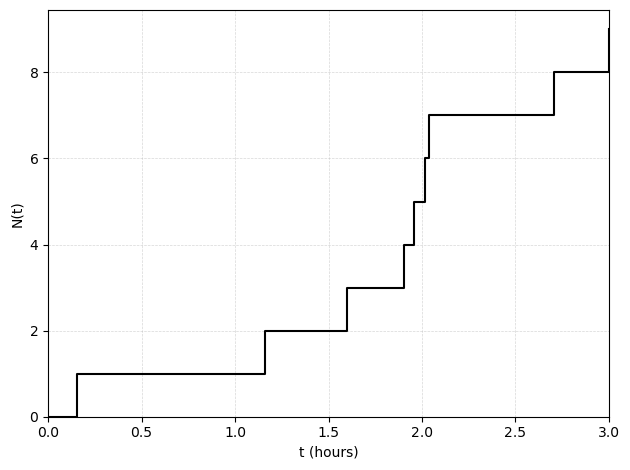

In [9]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

lam = 3.0
T_max = 3.0
d = 10/60  # 10 minutes in hours

# simulate arrival times in [0, T_max]
arrival_times = []
t = 0.0
while True:
    t += np.random.exponential(scale=1/lam)
    if t > T_max:
        break
    arrival_times.append(t)

arrival_times = np.array(arrival_times)

# build step function for N(t)
times = np.concatenate(([0.0], arrival_times, [T_max]))
counts = np.arange(0, len(times))

fig, ax = plt.subplots()
ax.step(times, counts, where="post", color="black", linewidth=1.5)

ax.set_xlabel("t (hours)")
ax.set_ylabel("N(t)")
ax.set_xlim(0, T_max)
ax.set_ylim(bottom=0)

for side in ["top", "right", "left", "bottom"]:
    ax.spines[side].set_visible(True)

ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()

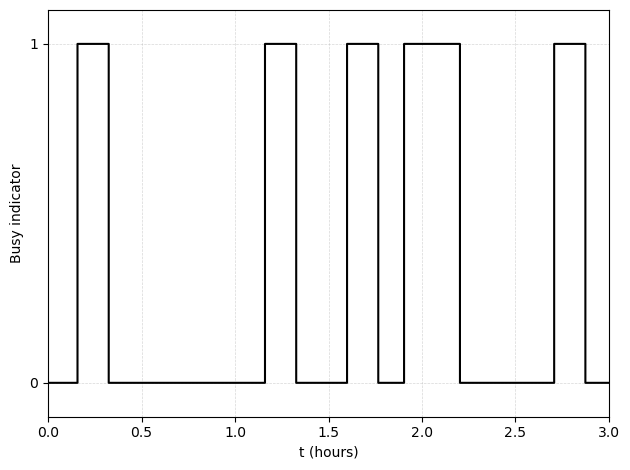

In [10]:
# time grid for plotting the busy indicator
dt = 0.001  # hours ~ 3.6 seconds
grid = np.arange(0, T_max + dt, dt)

busy = np.zeros_like(grid, dtype=int)

# for each grid time, check if there is an arrival in (t-d, t]
for i, tt in enumerate(grid):
    left = np.searchsorted(arrival_times, tt - d, side="right")
    right = np.searchsorted(arrival_times, tt, side="right")
    busy[i] = 1 if right > left else 0

fig, ax = plt.subplots()
ax.step(grid, busy, where="post", color="black", linewidth=1.5)

ax.set_xlabel("t (hours)")
ax.set_ylabel("Busy indicator")
ax.set_xlim(0, T_max)
ax.set_ylim(-0.1, 1.1)
ax.set_yticks([0, 1])

for side in ["top", "right", "left", "bottom"]:
    ax.spines[side].set_visible(True)

ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()

In [11]:
def simulate_arrivals(lam, T_total, seed=42):
    np.random.seed(seed)
    arr = []
    t = 0.0
    while True:
        t += np.random.exponential(scale=1/lam)
        if t > T_total:
            break
        arr.append(t)
    return np.array(arr)

def total_busy_time(arrivals, d, T_total):
    if arrivals.size == 0:
        return 0.0

    starts = arrivals
    ends = arrivals + d
    ends = np.minimum(ends, T_total)

    # merge intervals
    order = np.argsort(starts)
    starts = starts[order]
    ends = ends[order]

    busy_time = 0.0
    cur_s, cur_e = starts[0], ends[0]
    for s, e in zip(starts[1:], ends[1:]):
        if s <= cur_e:
            cur_e = max(cur_e, e)
        else:
            busy_time += cur_e - cur_s
            cur_s, cur_e = s, e
    busy_time += cur_e - cur_s
    return busy_time

lam = 3.0
d = 10/60
T_total = 500.0  # hours, long horizon

arr_long = simulate_arrivals(lam, T_total, seed=42)
busy_time = total_busy_time(arr_long, d, T_total)
busy_prop = busy_time / T_total

theory_busy = 1 - np.exp(-lam * d)

print("Sample estimate of busy proportion:", round(busy_prop, 4))
print("Theoretical busy probability:", round(theory_busy, 4))

Sample estimate of busy proportion: 0.3838
Theoretical busy probability: 0.3935
